In [1]:
print("test")

test


In [4]:
from datasets import load_dataset
import numpy as np


c:\Users\malak\Desktop\sma-sentiment-analysis-prompt-engineering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
dataset = load_dataset("imdb")

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at C:\Users\malak\.cache\huggingface\datasets\imdb\plain_text\0.0.0\e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Tue Mar 17 17:51:59 2026).


In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [7]:
train_df = dataset['train'].to_pandas()

In [8]:
train_df.sample(10)

,text,label
19872,I own Ralph Bakshis forgotten masterpiece Fire...,1
2251,"This movie is weak ,The box-cover says East LA...",0
7450,In this 'sequel' Bruce is still called Billy L...,0
11767,Scary Movie 2 was a grave disappointment. Simp...,0
4570,There's plenty to appreciate here: spectacular...,0
15537,BASEketball is one of the funniest movies I ha...,1
12072,Previous commentator Steve Richmond stated tha...,0
11048,"Probably the worst film I've ever seen, the ac...",0
15005,It's hard to say anything about a movie like t...,1
3006,That song keeps humming in my head. Not the gr...,0


In [ ]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [22]:
train_df['sentiment']= np.where(train_df.label==1,"positive","négative")

In [23]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,négative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,négative
2,If only to avoid making this type of film in t...,0,négative
3,This film was probably inspired by Godard's Ma...,0,négative
4,"Oh, brother...after hearing about this ridicul...",0,négative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [24]:
train_df.sentiment.value_counts()

sentiment
négative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

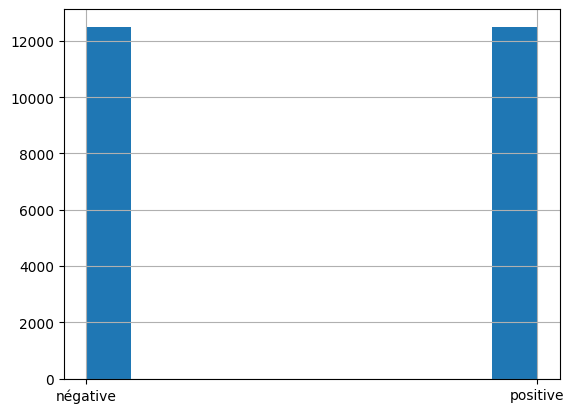

In [25]:
train_df.sentiment.hist()

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [28]:
examples_df.shape , gold_examples_df.shape

((20000, 3), (5000, 3))

In [60]:
columns = ['text' ,'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(20 , random_state=34)
                 .to_json(orient='records')
                 )

In [61]:
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
from datasets import load_dataset
from dotenv.ipython import load_dotenv
import matplotlib.pyplot  as plt


In [62]:
import json

In [63]:
json.loads(gold_examples)

[{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
  'sentiment': 'positive'},
 {'text': "I've had to change my view on the worst film in the 

In [64]:
user_message_template = """```{movie_review}```"""

In [65]:
zero_shot_prompt_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""

In [66]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_prompt_system_message}]

In [67]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [68]:
examples_df

,text,sentiment
24446,"Thanks Jymn Magon, for creating Disney's 2 bes...",positive
12874,"A series of random, seemingly insignificant th...",positive
22381,I watch them all.<br /><br />It's not better t...,positive
15703,Somebody mastered the difficult task of mergin...,positive
5299,Vovochka is your everyday hooligan vs authorit...,négative
4376,"Where to start? OK, don't compare this film to...",négative
5397,"EPSILON, a.k.a. ALIEN VISITOR, is not what I e...",négative
4491,A question for you : A family go to a new hous...,négative


In [69]:
positive_examples_df= examples_df[examples_df['sentiment'] == 'positive'][columns].sample(4)


In [70]:
negative_examples_df= examples_df[examples_df['sentiment'] == 'négative'][columns].sample(4)


In [71]:
positive_examples_df

,text,sentiment
12874,"A series of random, seemingly insignificant th...",positive
24446,"Thanks Jymn Magon, for creating Disney's 2 bes...",positive
15703,Somebody mastered the difficult task of mergin...,positive
22381,I watch them all.<br /><br />It's not better t...,positive


In [72]:
negative_examples_df

,text,sentiment
4491,A question for you : A family go to a new hous...,négative
5299,Vovochka is your everyday hooligan vs authorit...,négative
5397,"EPSILON, a.k.a. ALIEN VISITOR, is not what I e...",négative
4376,"Where to start? OK, don't compare this film to...",négative


In [73]:
positive_examples_df.shape , negative_examples_df.shape

((4, 2), (4, 2))

In [74]:
positive_exampls = (positive_examples_df[columns]
                     .sample(4)
                     .to_json(orient = 'records'))


In [76]:
negative_exampls = (negative_examples_df[columns]
                     .sample(4)
                     .to_json(orient = 'records'))

In [77]:
json.loads(positive_exampls)

[{'text': "Thanks Jymn Magon, for creating Disney's 2 best cartoons ever. This show has improved very much over the years. As a kid, I didn't like it because I thought it was a rip-off of Ducktales, which was my favorite Disney thing at the time (like Grandmoffromero). Then later on though it was good but not great. But after reading the reviews here, I decided to give it another chance & bought the DVD set & watched the whole pilot the first day I got it, & was very pleasantly surprised. It's still my favorite episode, although the series did live up to it. And by the end of disc 1, I knew this was going to be a top tenner.<br /><br />The characters are so complex & charming. My favorite has got to be Wildcat. He's absolutely hilarious and sweet to boot. My next favorite is Baloo, the best pilot on the show. I can see why 'ol Jymn built the show around him. Then it's Kit Cloudkicker. He & Baloo have the best relationship in the series. After that, Louie. Jim Cummings did a perfect job

In [78]:
json.loads(negative_exampls)

[{'text': 'EPSILON, a.k.a. ALIEN VISITOR, is not what I expected. This is a no-budget Australian film with no special effects other than speeded-up film and quick scene cuts. The female alien (who comes over immediately able to speak perfectly accented Australian) can "blip" from place to place or time to time and alter her perception of the flow of time to match the "faster" humans.<br /><br />An elderly grandmother tells her two granddaughters about a story a wandering man told her 40 years before, when an unnamed "She" came to the planet naked and completely disoriented, unable to recognize which star in the sky she came from...She meets a man alone camping in the Australian Outback, apparently bewildering him. She is here by "mistake", and gets angry when she is told she is on Earth. The Earthlings are known as consummate despoilers of the environment and a metaphor for the most insulting thing imaginable to the rest of the universe: those who "breathe the foul air" but do nothing 

In [79]:
positive_examples_df

,text,sentiment
12874,"A series of random, seemingly insignificant th...",positive
24446,"Thanks Jymn Magon, for creating Disney's 2 bes...",positive
15703,Somebody mastered the difficult task of mergin...,positive
22381,I watch them all.<br /><br />It's not better t...,positive


In [80]:
negative_examples_df

,text,sentiment
4491,A question for you : A family go to a new hous...,négative
5299,Vovochka is your everyday hooligan vs authorit...,négative
5397,"EPSILON, a.k.a. ALIEN VISITOR, is not what I e...",négative
4376,"Where to start? OK, don't compare this film to...",négative


In [81]:
positive_examples_df.shape , negative_examples_df.shape

((4, 2), (4, 2))

In [82]:
import  pandas as pd

In [83]:
examples_df= pd.concat([positive_examples_df,  negative_examples_df])

In [84]:
examples_df

,text,sentiment
12874,"A series of random, seemingly insignificant th...",positive
24446,"Thanks Jymn Magon, for creating Disney's 2 bes...",positive
15703,Somebody mastered the difficult task of mergin...,positive
22381,I watch them all.<br /><br />It's not better t...,positive
4491,A question for you : A family go to a new hous...,négative
5299,Vovochka is your everyday hooligan vs authorit...,négative
5397,"EPSILON, a.k.a. ALIEN VISITOR, is not what I e...",négative
4376,"Where to start? OK, don't compare this film to...",négative


In [85]:
examples = examples_df.sample(4*2 , replace=False).to_json(orient='records')

In [86]:
json.loads(examples)

[{'text': "Where to start? OK, don't compare this film to fight club for a start - ridiculous. If it was even a patch on fight club, the violence, blood, gore etc would be much more evident and realistic. Secondly, this film is no football factory - which is so much more real (and Danny Dyer makes Nicholas Nickelby look like an embarrassment). Fair enough, the storyline is quite decent and the fight scenes are well choreographed - with a decent ending i might add. But the film on the whole is poor, seriously poor. As people have been mentioning the accents should not spoil a film - i disagree - either a simple casting error, or a lack of effort in coaching the voices caused the film to be irritating all the way through - it was obvious from scene one some American/Geordie was playing the role. Don't get me wrong, good looking guy, who looks great with a skin head - but no not a football hooligan. I could go on forever about how ridiculous the football scene was - the 'fake steward' sit

In [97]:
def create_examples(dataset, n=4):
    columns_to_select = ['text', 'sentiment']
    pos = dataset.loc[dataset.sentiment == 'positive', columns_to_select]
    neg = dataset.loc[dataset.sentiment == 'negative', columns_to_select]

    pos_n = min(n, len(pos))
    neg_n = min(n, len(neg))

    pos_examples = pos.sample(pos_n)
    neg_examples = neg.sample(neg_n)

    examples = pd.concat([pos_examples, neg_examples])
    randomized = examples.sample(len(examples), replace=False)

    # Return as list of dicts
    return randomized.to_dict(orient='records')


In [98]:
examples = create_examples(examples_df,2)

In [114]:
examples = create_examples(examples_df, 2)   # already a list of dicts
print(type(examples))  # should be <class 'list'>
print(examples)        # list of dicts


<class 'list'>
[{'text': "Thanks Jymn Magon, for creating Disney's 2 best cartoons ever. This show has improved very much over the years. As a kid, I didn't like it because I thought it was a rip-off of Ducktales, which was my favorite Disney thing at the time (like Grandmoffromero). Then later on though it was good but not great. But after reading the reviews here, I decided to give it another chance & bought the DVD set & watched the whole pilot the first day I got it, & was very pleasantly surprised. It's still my favorite episode, although the series did live up to it. And by the end of disc 1, I knew this was going to be a top tenner.<br /><br />The characters are so complex & charming. My favorite has got to be Wildcat. He's absolutely hilarious and sweet to boot. My next favorite is Baloo, the best pilot on the show. I can see why 'ol Jymn built the show around him. Then it's Kit Cloudkicker. He & Baloo have the best relationship in the series. After that, Louie. Jim Cummings di

In [115]:
def create_prompt(system_message, examples, user_message_template):
    prompt = [{'role':'system', 'content': system_message}]
    for example in examples:   # already a list of dicts
        review = example['text']
        sentiment = example['sentiment']
        prompt.append({
            "role":"user",
            "content": user_message_template.format(movie_review=review)
        })
        prompt.append({"role":"assistant", "content": sentiment})
    return prompt


In [101]:
few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)

In [102]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': '```I watch them all.<br /><br />It\'s not better than the amazing ones (_Strictly Ballroom_, _Shall we dance?_ (Japanese version), but it\'s completely respectable and pleasingly different in parts.<br /><br />I am an English teacher and I find some of the ignorance about language in some of these reviews rather upsetting. For example: the "name should scream don\'t watch. \'How she move.\' Since when can movie titles ignore grammar?" <br /><br />There is nothing inherently incorrect about Caribbean English grammar. It\'s just not Canadian standard English grammar. Comments about the dialogue seem off to me. I put on the subtitles because I\'m a Canadian standard English speaker, so I just AUT

In [103]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [104]:
cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

In [105]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative' \nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive\n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n"},
 {'role': 'user',
  'content': '```I watch them all.<br /><br />It\'s not better than the amazing ones (_Strictly Ballroom_, _Shall we dance?_ (Japanese version), but it\'s completely respectable and pleasingly different in parts.<br /><br />I am an English teacher and I find some of the ignorance about language in some of these reviews rather upsetting. For example: the "name should scream don\'t watch. \'How she mo

In [106]:
import json
from sklearn.metrics import f1_score

def evaluate_prompt(prompt, gold_examples, user_message_template, model):
    model_predictions, ground_truths = [], []

    for example in json.loads(gold_examples):
        gold_input = example['text']
        user_input = [
            {
                'role': 'user',
                'content': user_message_template.format(movie_review=gold_input)
            }
        ]
        try:
            # Appel au modèle
            response = model.invoke(prompt + user_input)

            # Récupérer le texte de sortie (à adapter selon ton SDK)
            response_content = response[0]['content'] if isinstance(response, list) else response['content']

            # Déterminer la prédiction
            if 'négative' in response_content.strip().lower():
                prediction = 'négative'
            elif 'positive' in response_content.strip().lower():
                prediction = 'positive'
            else:
                prediction = 'unknown'

            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])

            # Afficher chaque comparaison
            print("Prédiction:", prediction, "| Vérité:", example['sentiment'])

        except Exception as e:
            print("Erreur:", e)
            continue

    # Calcul du score F1
    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    return micro_f1_score

# Exemple d’appel
#score = evaluate_prompt(prompt, gold_examples, "Analyse du film: {movie_review}", model)
#print("Score F1 micro:", score)


In [123]:
from dotenv import load_dotenv
import os

load_dotenv()  # charge le fichier .env
api_key = os.getenv("OPENAI_API_KEY")

from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI

gpt5 = ChatOpenAI(
    model="gpt-4.1-mini",  # ou un modèle disponible
    temperature=0,
    api_key=api_key
)


In [124]:
response = gpt5.invoke([{"role":"user","content":"Hello!"}])
print(response)


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [122]:
response = gpt5.invoke(zero_shot_prompt)
print(response)


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [121]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template, gpt5)

Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-*********************************************************************************************

ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [109]:
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt5)

Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-*********************************************************************************************

ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [110]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template, gpt5)

Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-*********************************************************************************************

ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [111]:
num_eval_runs = 10
few_shot_performance, cot_few_shot_performance = [], []
for _ in tqdm(range(num_eval_runs)):

    # For each run create a new sample of examples
    examples = create_examples(examples_df)

    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)
    #cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

    # Evaluate prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt5)
    #cot_few_shot_micro_f1 = evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template)

    few_shot_performance.append(few_shot_micro_f1)
    cot_few_shot_performance.append(few_shot_micro_f1)

  0%|          | 0/10 [00:00<?, ?it/s]

Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-*********************************************************************************************

  0%|          | 0/10 [00:05<?, ?it/s]

Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Erreur: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}


ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [112]:
mean_val =np.array(few_shot_performance).mean()
std_val= np.array(few_shot_performance).std()

C:\Users\malak\AppData\Local\Temp\ipykernel_19572\3542689840.py:1: RuntimeWarning: Mean of empty slice
  mean_val =np.array(few_shot_performance).mean()
c:\Users\malak\Desktop\sma-sentiment-analysis-prompt-engineering\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\malak\Desktop\sma-sentiment-analysis-prompt-engineering\.venv\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\malak\Desktop\sma-sentiment-analysis-prompt-engineering\.venv\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\malak\Desktop\sma-sentiment-analysis-prompt-engineering\.venv\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  re

In [113]:
print(f"f1_score Moyen= {mean_val}, Standard Deviation = {std_val} ")

f1_score Moyen= nan, Standard Deviation = nan 
